<a href="https://colab.research.google.com/github/ysn-gachon/AI-Class-202335225-nayeonsu/blob/main/Week12/TSLA_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import pandas as pd

# 1. 데이터 로드
TSLA = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TSLA.csv')
print(TSLA)


            Date         Open         High         Low        Close  \
0     2010-06-29     3.800000     5.000000    3.508000     4.778000   
1     2010-06-30     5.158000     6.084000    4.660000     4.766000   
2     2010-07-01     5.000000     5.184000    4.054000     4.392000   
3     2010-07-02     4.600000     4.620000    3.742000     3.840000   
4     2010-07-06     4.000000     4.000000    3.166000     3.222000   
...          ...          ...          ...         ...          ...   
2951  2022-03-18   874.489990   907.849976  867.390015   905.390015   
2952  2022-03-21   914.979980   942.849976  907.090027   921.159973   
2953  2022-03-22   930.000000   997.859985  921.750000   993.979980   
2954  2022-03-23   979.940002  1040.699951  976.400024   999.109985   
2955  2022-03-24  1009.729980  1024.489990  988.799988  1013.919983   

        Adj Close    Volume  
0        4.778000  93831500  
1        4.766000  85935500  
2        4.392000  41094000  
3        3.840000  25699000

In [31]:
openValues = TSLA[['Open']]

In [32]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
openValues = scaler.fit_transform(openValues)

In [38]:
TEST_SIZE = 600
train = openValues[:-TEST_SIZE]
test = openValues[-TEST_SIZE:]

In [39]:
def make_sample(data, window):
  train = []
  target = []
  for i in range(len(data)-window):
    train.append(data[i:i+window])
    target.append(data[i+window])
  return np.array(train), np.array(target)

X_train, y_train = make_sample(train, 50)
X_test, y_test = make_sample(test, 50)

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
model = Sequential()
model.add(SimpleRNN(10,
                    input_shape=(10, 1),
                    activation='tanh'))
model.add(Dense(1, activation='tanh'))
model.compile(loss='mse', optimizer='adam')
model.fit(X_train, y_train, epochs=100, batch_size=16)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 2.8799e-04
Epoch 2/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.8078e-06
Epoch 3/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.7581e-06
Epoch 4/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.6331e-06
Epoch 5/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 4.9640e-06
Epoch 6/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 4.5408e-06
Epoch 7/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.4965e-06
Epoch 8/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.0512e-06
Epoch 9/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.8940e-06
Epoch 10/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.6112e-06
Epoch 11/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.5983e-06
Epoch 12/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.3495e-06
Epoch 13/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.3102e-06
Epoch 14/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.2617e-

In [41]:
pred = model.predict(X_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


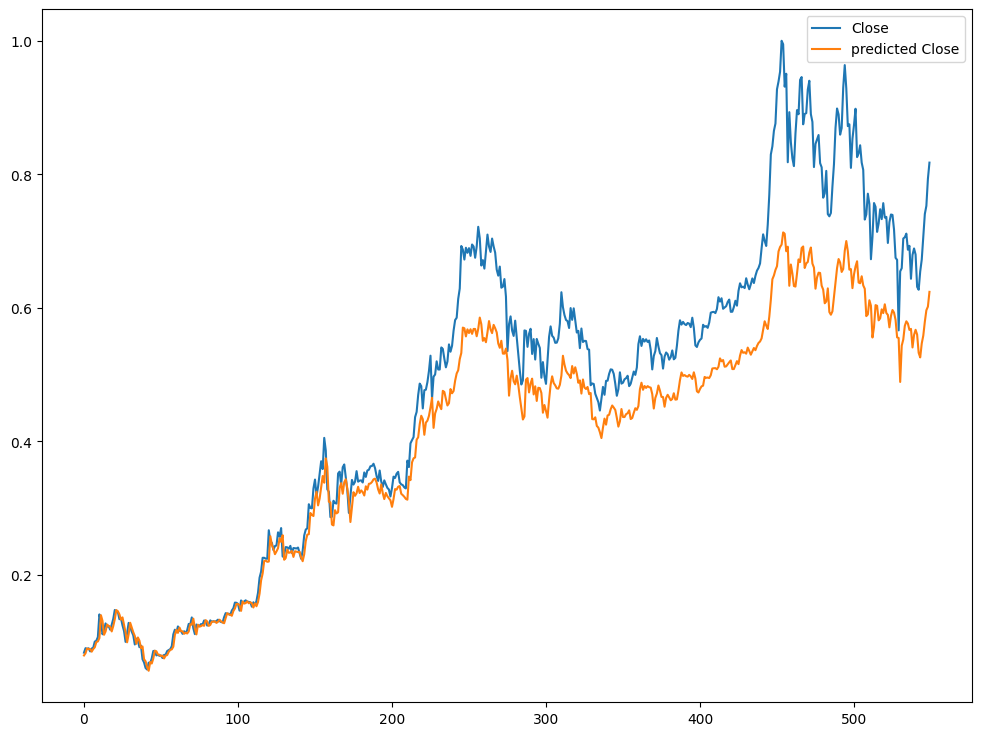

In [42]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 9))
plt.plot(y_test, label='Open')
plt.plot(pred, label='predicted Open')
plt.legend()
plt.show()